In [1]:
import pandas as pd

In [5]:
df = pd.read_csv("D:/BOOTCAMP/CARPETA_BARBARA/ML_MICROBIOME/ML/data/abundance_stoolsubset.csv")

C:\Users\gonza\AppData\Local\Temp\ipykernel_13512\453139285.py:1: DtypeWarning: Columns (5,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("D:/BOOTCAMP/CARPETA_BARBARA/ML_MICROBIOME/ML/data/abundance_stoolsubset.csv")


In [6]:
df.head()

,dataset_name,sampleID,subjectID,bodysite,disease,age,gender,country,sequencing_technology,pubmedid,...,k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactobacillales|f__Enterococcaceae|g__Enterococcus|s__Enterococcus_gilvus|t__Enterococcus_gilvus_unclassified,k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactobacillales|f__Lactobacillaceae|g__Lactobacillus|s__Lactobacillus_otakiensis,k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactobacillales|f__Lactobacillaceae|g__Lactobacillus|s__Lactobacillus_otakiensis|t__GCF_000415925,k__Bacteria|p__Firmicutes|c__Clostridia|o__Clostridiales|f__Peptococcaceae,k__Bacteria|p__Firmicutes|c__Clostridia|o__Clostridiales|f__Peptococcaceae|g__Desulfotomaculum,k__Bacteria|p__Firmicutes|c__Clostridia|o__Clostridiales|f__Peptococcaceae|g__Desulfotomaculum|s__Desulfotomaculum_ruminis,k__Bacteria|p__Firmicutes|c__Clostridia|o__Clostridiales|f__Peptococcaceae|g__Desulfotomaculum|s__Desulfotomaculum_ruminis|t__GCF_000215085,k__Bacteria|p__Firmicutes|c__Clostridia|o__Clostridiales|f__Ruminococcaceae|g__Faecalibacterium|s__Faecalibacterium_prausnitzii|t__GCF_000209855,k__Bacteria|p__Firmicutes|c__Negativicutes|o__Selenomonadales|f__Veillonellaceae|g__Megasphaera|s__Megasphaera_sp_BV3C16_1,k__Bacteria|p__Firmicutes|c__Negativicutes|o__Selenomonadales|f__Veillonellaceae|g__Megasphaera|s__Megasphaera_sp_BV3C16_1|t__GCF_000478965
0,Candela_Africa,H10,h10,stool,n,40,female,tanzania,Illumina,25981789,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Candela_Africa,H11,h11,stool,n,29,female,tanzania,Illumina,25981789,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Candela_Africa,H12,h12,stool,n,8,female,tanzania,Illumina,25981789,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Candela_Africa,H13,h13,stool,n,34,male,tanzania,Illumina,25981789,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Candela_Africa,H14,h14,stool,n,30,male,tanzania,Illumina,25981789,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1989 entries, 0 to 1988
Columns: 2339 entries, dataset_name to k__Bacteria|p__Firmicutes|c__Negativicutes|o__Selenomonadales|f__Veillonellaceae|g__Megasphaera|s__Megasphaera_sp_BV3C16_1|t__GCF_000478965
dtypes: float64(2128), int64(1), object(210)
memory usage: 35.5+ MB


In [8]:
df.shape

(1989, 2339)

In [26]:
df["disease"].value_counts()

disease
n                             944
t2d                           223
obesity                       164
ibd_ulcerative_colitis        148
cirrhosis                     118
leaness                        89
stec2-positive                 52
impaired_glucose_tolerance     49
cancer                         48
n_relative                     47
small_adenoma                  26
ibd_crohn_disease              25
 -                             20
large_adenoma                  13
overweight                     10
-                               7
obese                           5
underweight                     1
Name: count, dtype: int64

In [27]:
df_plot = df[df["disease"].isin(["n", "t2d", "obesity", "ibd_ulcerative_colitis"])].copy()

In [28]:
df_plot["disease"].value_counts()

disease
n                         944
t2d                       223
obesity                   164
ibd_ulcerative_colitis    148
Name: count, dtype: int64

c:\Users\gonza\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
c:\Users\gonza\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


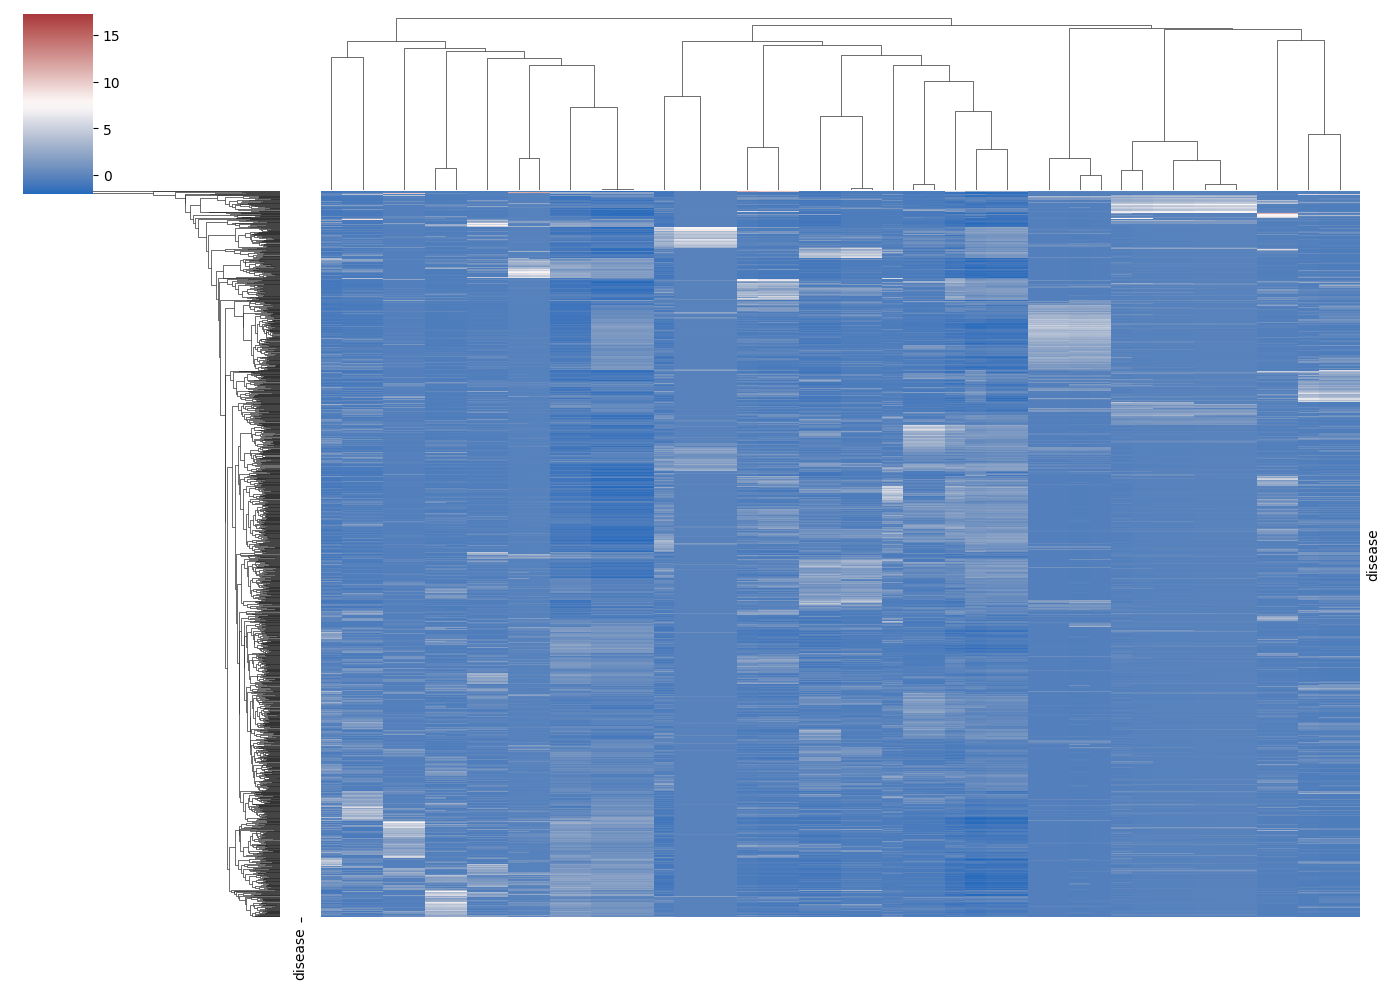

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("D:/BOOTCAMP/CARPETA_BARBARA/ML_MICROBIOME/ML/data/abundance_stoolsubset.csv", low_memory=False)

# Nos quedamos con algunas clases para que el gráfico sea legible
df_plot = df[df["disease"].isin(["n", "t2d", "obesity", "ibd_ulcerative_colitis"])].copy()

# Columnas microbianas: empiezan por k__
microbe_cols = [col for col in df_plot.columns if col.startswith("k__")]

# Convertir abundancias a numérico
X = df_plot[microbe_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

# Seleccionar las 50 especies/taxones con más varianza
top_features = X.var().sort_values(ascending=False).head(50).index
X_top = X[top_features]

# Escalado para visualizar patrones relativos
X_scaled = pd.DataFrame(
    StandardScaler().fit_transform(X_top),
    columns=X_top.columns,
    index=df_plot["disease"]
)

# Colores por enfermedad
disease_palette = {
    "n": "#4C78A8",
    "t2d": "#F58518",
    "obesity": "#54A24B",
    "ibd_ulcerative_colitis": "#E45756"
}

row_colors = df_plot["disease"].map(disease_palette)

sns.clustermap(
    X_scaled,
    cmap="vlag",
    row_colors=row_colors,
    figsize=(14, 10),
    xticklabels=False,
    yticklabels=False,
    standard_scale=None
)

plt.show()

In [15]:
import pandas as pd

def extract_tax_level(taxon, level="p__"):
    parts = taxon.split("|")
    for part in parts:
        if part.startswith(level):
            return part
    return "unknown"

def aggregate_taxa_by_level(df, level="p__"):
    microbe_cols = [col for col in df.columns if col.startswith("k__")]

    X = df[microbe_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

    grouped_names = [extract_tax_level(col, level=level) for col in microbe_cols]

    X_grouped = X.T.groupby(grouped_names).sum().T

    if "unknown" in X_grouped.columns:
        X_grouped = X_grouped.drop(columns=["unknown"])

    return X_grouped

In [16]:
X_phylum = aggregate_taxa_by_level(df, level="p__")
X_phylum.shape

(1989, 23)

In [17]:
X_class = aggregate_taxa_by_level(df, level="c__")
X_class.shape

(1989, 38)

c:\Users\gonza\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
c:\Users\gonza\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


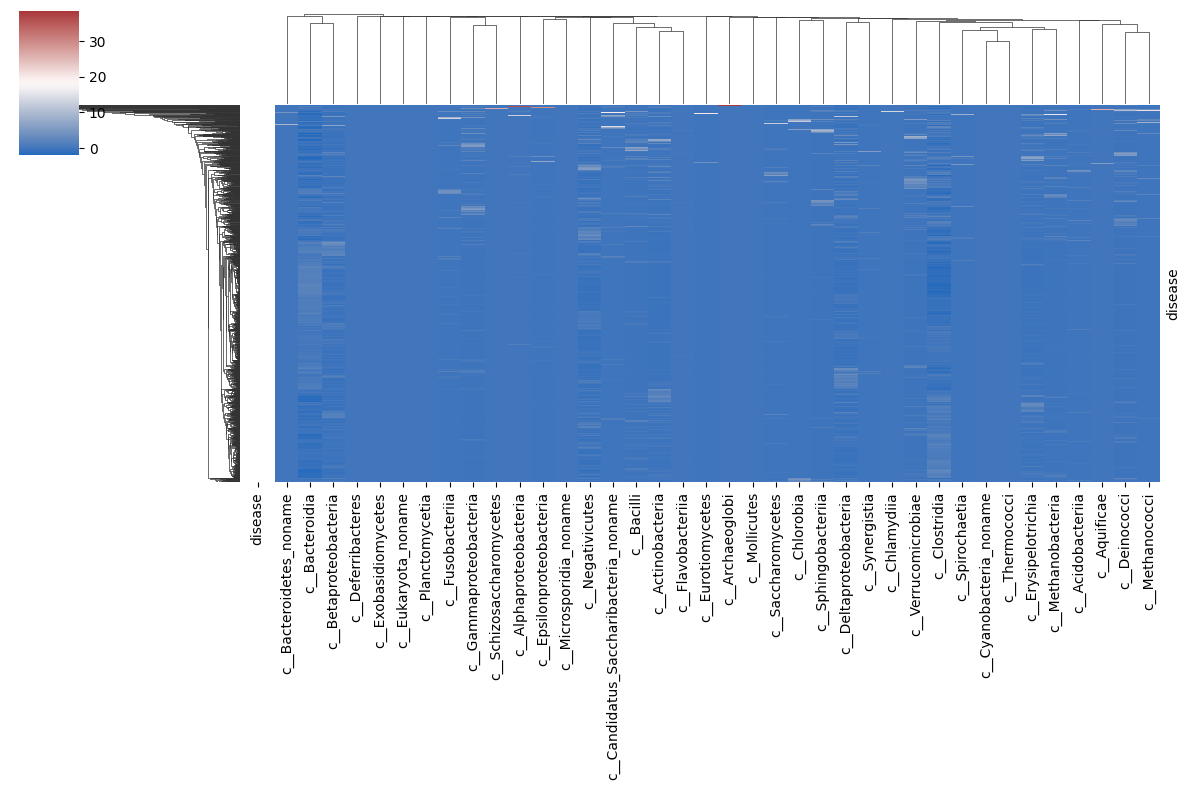

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

df_plot = df[df["disease"].isin(["n", "t2d", "obesity", "ibd_ulcerative_colitis"])].copy()

X_class = aggregate_taxa_by_level(df_plot, level="c__")

X_scaled = pd.DataFrame(
    StandardScaler().fit_transform(X_class),
    columns=X_class.columns,
    index=df_plot["disease"]
)

row_colors = df_plot["disease"].map({
    "n": "#4C78A8",
    "t2d": "#F58518",
    "obesity": "#54A24B",
    "ibd_ulcerative_colitis": "#E45756"
})

sns.clustermap(
    X_scaled,
    cmap="vlag",
    row_colors=row_colors,
    figsize=(12, 8),
    xticklabels=True,
    yticklabels=False
)

plt.show()

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def extract_tax_level(taxon, level="c__"):
    parts = taxon.split("|")
    for part in parts:
        if part.startswith(level):
            return part
    return "unknown"

def aggregate_taxa_by_level(df, level="c__"):
    microbe_cols = [col for col in df.columns if col.startswith("k__")]
    X = df[microbe_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

    grouped_names = [extract_tax_level(col, level=level) for col in microbe_cols]
    X_grouped = X.T.groupby(grouped_names).sum().T

    if "unknown" in X_grouped.columns:
        X_grouped = X_grouped.drop(columns=["unknown"])

    return X_grouped

In [33]:
selected_diseases = [
    "n",
    "t2d",
    "obesity",
    "ibd_ulcerative_colitis",
    "cirrhosis"
]

df_plot = df[df["disease"].isin(selected_diseases)].copy()

In [34]:
X_class = aggregate_taxa_by_level(df_plot, level="c__")

In [35]:
X_class["disease"] = df_plot["disease"].values

heatmap_data = X_class.groupby("disease").mean().T

In [36]:
heatmap_data_scaled = heatmap_data.sub(heatmap_data.mean(axis=1), axis=0)
heatmap_data_scaled = heatmap_data_scaled.div(heatmap_data.std(axis=1), axis=0)

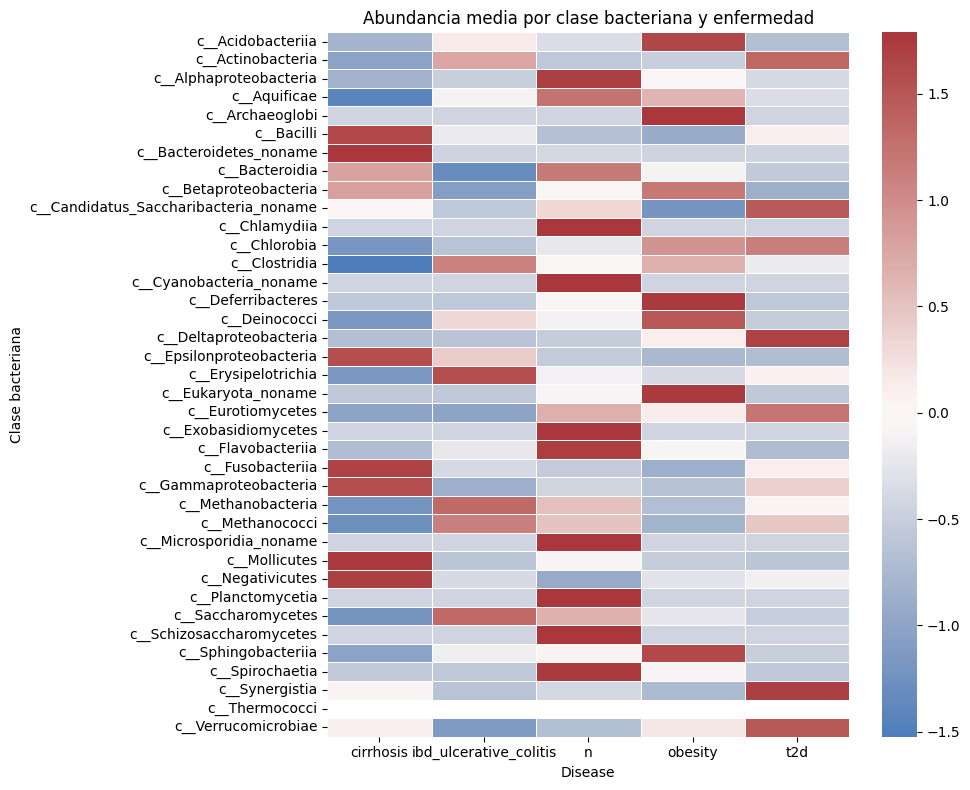

In [37]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    heatmap_data_scaled,
    cmap="vlag",
    center=0,
    linewidths=0.5
)

plt.title("Abundancia media por clase bacteriana y enfermedad")
plt.xlabel("Disease")
plt.ylabel("Clase bacteriana")
plt.tight_layout()
plt.show()

In [38]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def extract_tax_level(taxon, level="c__"):
    parts = taxon.split("|")
    for part in parts:
        if part.startswith(level):
            return part
    return "unknown"

def aggregate_taxa_by_level(df, level="c__"):
    microbe_cols = [col for col in df.columns if col.startswith("k__")]

    X = df[microbe_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

    grouped_names = [extract_tax_level(col, level=level) for col in microbe_cols]

    X_grouped = X.T.groupby(grouped_names).sum().T

    if "unknown" in X_grouped.columns:
        X_grouped = X_grouped.drop(columns=["unknown"])

    return X_grouped

In [39]:
invalid_diseases = ["nd", "-", " -"]

df_plot = df[~df["disease"].isin(invalid_diseases)].copy()

In [40]:
X_class = aggregate_taxa_by_level(df_plot, level="c__")

In [41]:
X_class["disease"] = df_plot["disease"].values

heatmap_data = X_class.groupby("disease").mean().T

In [42]:
heatmap_data_scaled = heatmap_data.sub(heatmap_data.mean(axis=1), axis=0)
heatmap_data_scaled = heatmap_data_scaled.div(heatmap_data.std(axis=1), axis=0)
heatmap_data_scaled = heatmap_data_scaled.fillna(0)

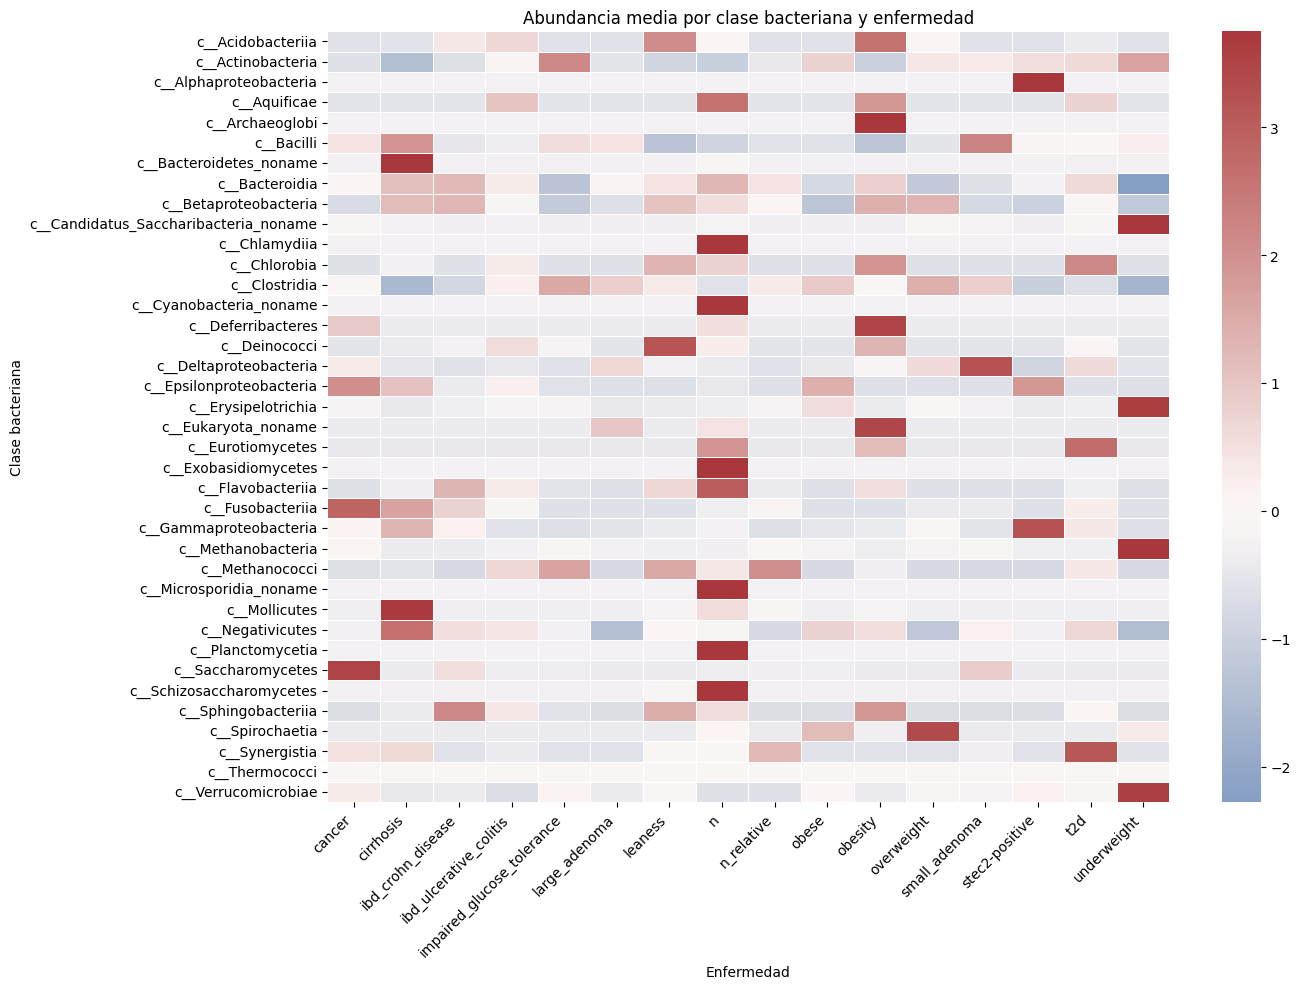

In [43]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    heatmap_data_scaled,
    cmap="vlag",
    center=0,
    linewidths=0.4
)

plt.title("Abundancia media por clase bacteriana y enfermedad")
plt.xlabel("Enfermedad")
plt.ylabel("Clase bacteriana")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

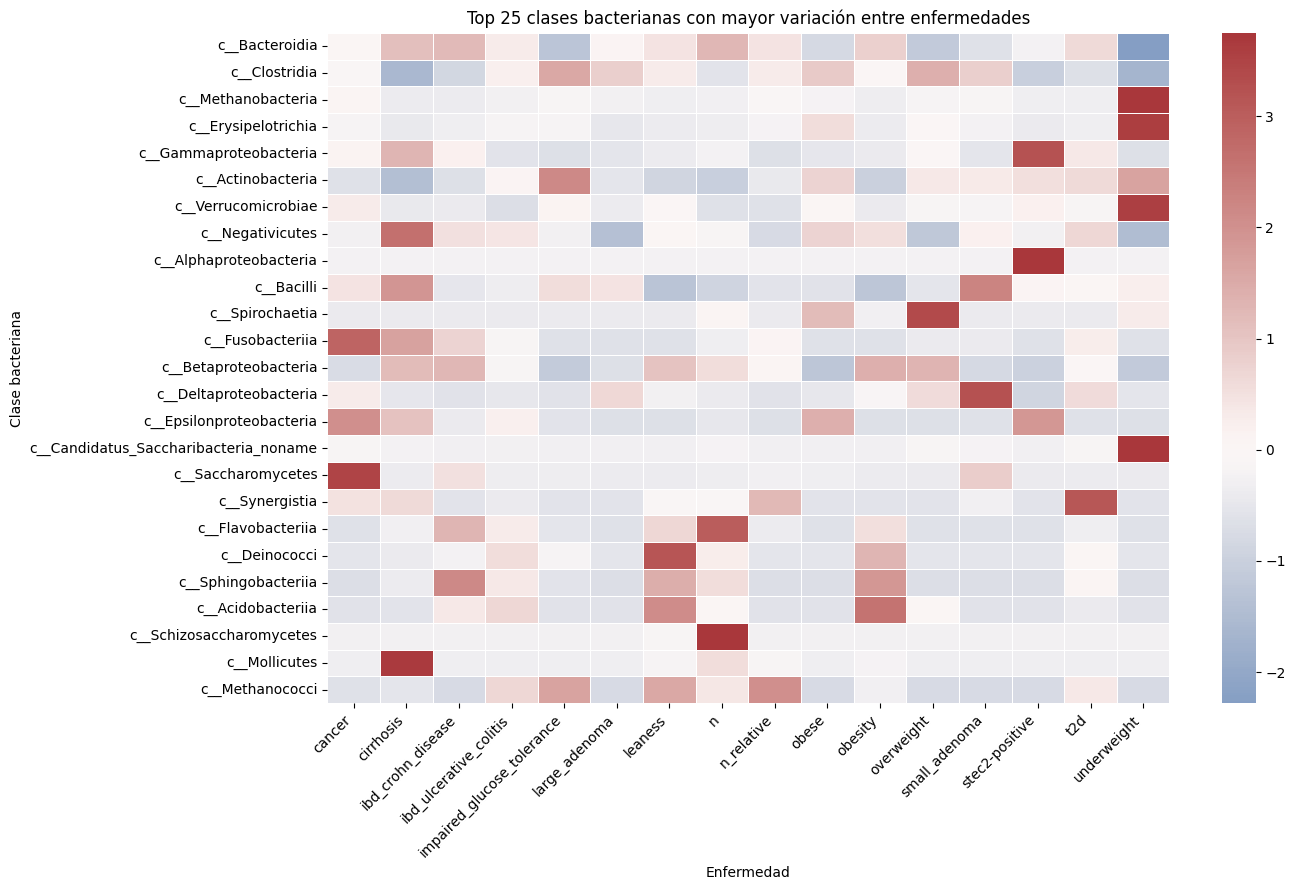

In [44]:
top_classes = heatmap_data.var(axis=1).sort_values(ascending=False).head(25).index

plt.figure(figsize=(14, 9))

sns.heatmap(
    heatmap_data_scaled.loc[top_classes],
    cmap="vlag",
    center=0,
    linewidths=0.4
)

plt.title("Top 25 clases bacterianas con mayor variación entre enfermedades")
plt.xlabel("Enfermedad")
plt.ylabel("Clase bacteriana")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

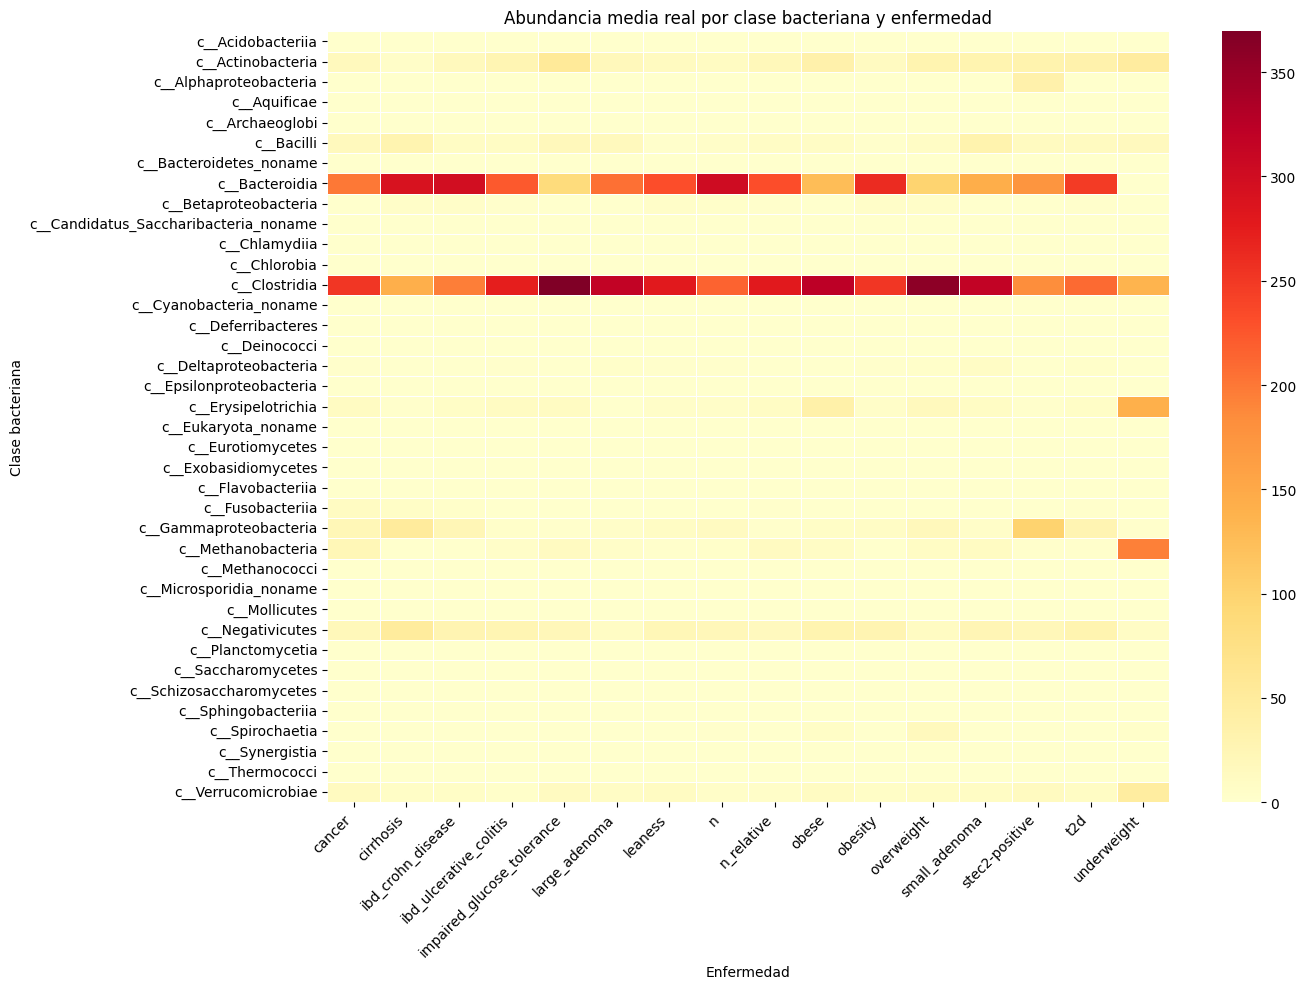

In [45]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",
    linewidths=0.4
)

plt.title("Abundancia media real por clase bacteriana y enfermedad")
plt.xlabel("Enfermedad")
plt.ylabel("Clase bacteriana")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [46]:
reference = heatmap_data["n"]

heatmap_vs_healthy = heatmap_data.sub(reference, axis=0)

In [47]:
heatmap_vs_healthy_pct = heatmap_data.div(reference.replace(0, pd.NA), axis=0) - 1
heatmap_vs_healthy_pct = heatmap_vs_healthy_pct.fillna(0)

C:\Users\gonza\AppData\Local\Temp\ipykernel_13512\1400699459.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  heatmap_vs_healthy_pct = heatmap_vs_healthy_pct.fillna(0)


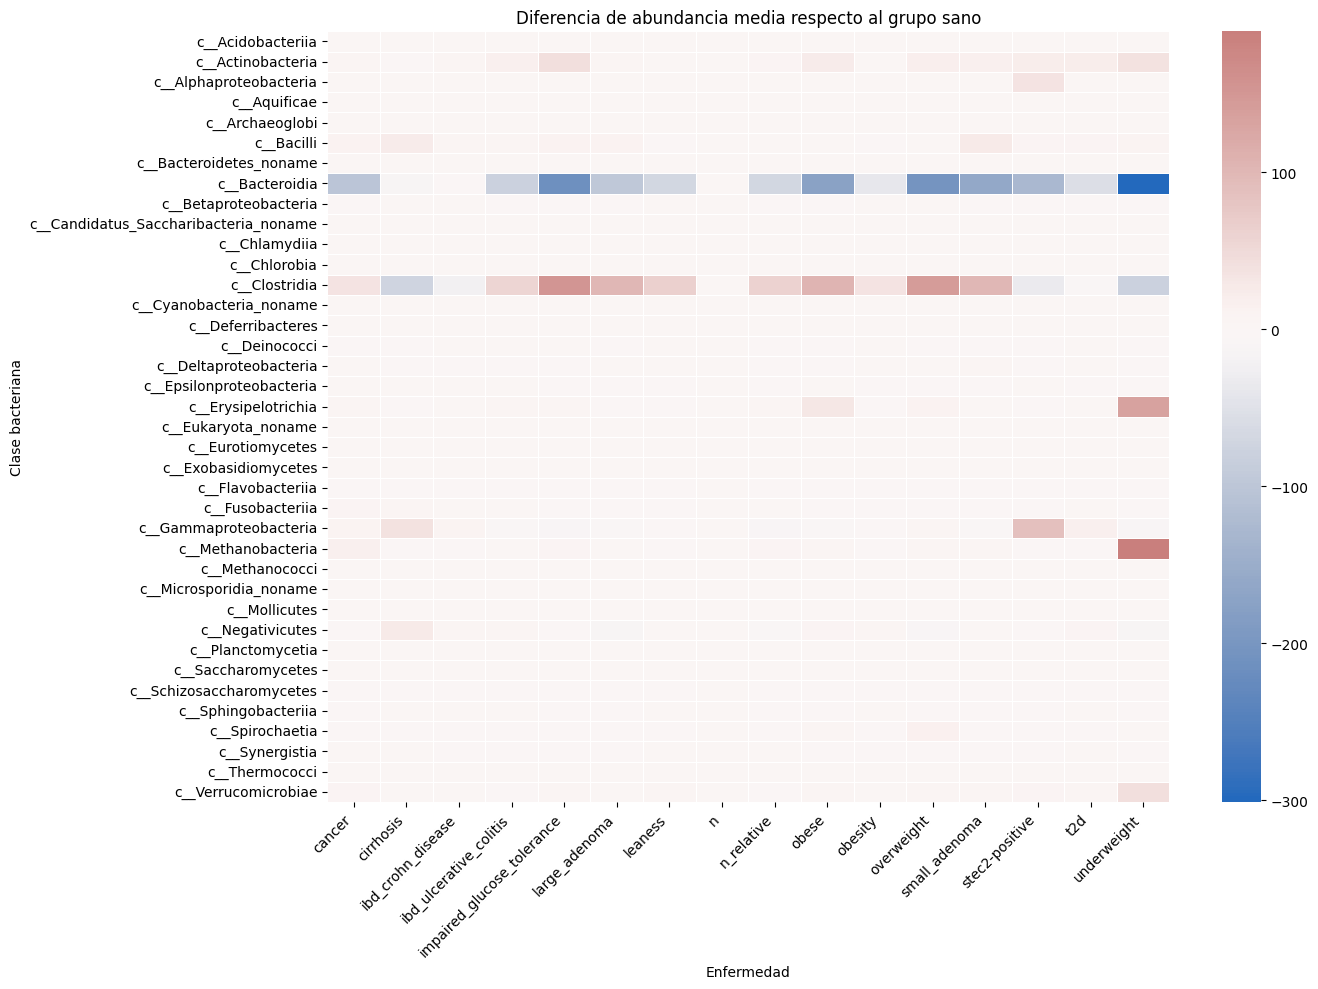

In [48]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    heatmap_vs_healthy,
    cmap="vlag",
    center=0,
    linewidths=0.4
)

plt.title("Diferencia de abundancia media respecto al grupo sano")
plt.xlabel("Enfermedad")
plt.ylabel("Clase bacteriana")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()